# Raman Single-Spectrum Backend Resolution Demo

**v0.4.8 — canonical backend-behaviour example**

This notebook demonstrates that RamanSPy can be used as a preprocessing backend for
**single-spectrum Raman fits**, not only for mapping.

## What this notebook shows

| Backend requested | Outcome |
|-------------------|---------|
| `"native"` | always uses the built-in NumPy path |
| `"auto"` | uses RamanSPy when available and the pipeline is translatable |
| `"ramanspy"` | forces RamanSPy; raises if unavailable or pipeline is not translatable |

The pipeline used here is **fully translatable**:
- `CropByRange` — supported
- `SmoothSavGol` — supported
- `BaselineSubtract(method="poly")` — supported

So `auto` will resolve to RamanSPy if it is installed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ramanpl import RamanFit
from ramanpl.preprocessing import Pipeline, CropByRange, SmoothSavGol, BaselineSubtract

## 1. Load a Raman spectrum

In [2]:
spectra, wavenumber = RamanFit.DataImporter.data_import(
    filename='Raman Sample MoS2 2D Flakes.wdf',
    x_range=(250, 750),
)
print(f"Loaded spectrum: {wavenumber.size} points, {wavenumber[0]:.0f}–{wavenumber[-1]:.0f} cm⁻¹")

# Update fitting bounds
custom_peaks = dict(
    E12g=([380, 0, 0], [385, 3, 10]),
    A1g= ([404, 0, 0], [408, 3, 20]),
    Si=  ([520, 0, 0], [525, 2, 30]),
)

Loaded spectrum: 270 points, 749–252 cm⁻¹


## 2. Define a fully translatable preprocessing pipeline

All three steps are in the RamanSPy-supported set, so `auto` will resolve to RamanSPy
when RamanSPy is installed.

In [3]:
PIPELINE_STEPS = [
    CropByRange((250, 750)),
    SmoothSavGol(window_length=11, polyorder=9),
    BaselineSubtract({"method": "arpls", "lam": 1e6, "niter": 50, "tol": 1e-6}),
]

## 3. Run with `backend="native"`

In [4]:
pipe_native = Pipeline(steps=PIPELINE_STEPS, backend="native")

fit_native = RamanFit.RamanFit(
    spectra=spectra,
    wavenumber=wavenumber,
    custom_peaks = custom_peaks,
    normalize=False,
    preprocessing=pipe_native,
)

fit_native.fit_spectrum()

outcome_native = fit_native._backend_outcome
print("requested:", outcome_native["requested_backend"])
print("resolved :", outcome_native["resolved_backend"])
print("fallback :", outcome_native["fallback_used"])

requested: native
resolved : native
fallback : False


## 4. Run with `backend="auto"`

With a fully translatable pipeline and RamanSPy installed, `auto` resolves to `ramanspy`.

In [5]:
pipe_auto = Pipeline(steps=PIPELINE_STEPS, backend="auto")

fit_auto = RamanFit.RamanFit(
    spectra=spectra,
    wavenumber=wavenumber,
    custom_peaks = custom_peaks,
    normalize=False,
    preprocessing=pipe_auto,
)
fit_auto.fit_spectrum()

outcome_auto = fit_auto._backend_outcome
print("requested:", outcome_auto["requested_backend"])
print("resolved :", outcome_auto["resolved_backend"])
print("fallback :", outcome_auto["fallback_used"])
if outcome_auto["fallback_used"]:
    print("reason   :", outcome_auto["fallback_reason"])

requested: auto
resolved : ramanspy
fallback : False


## 5. Run with `backend="ramanspy"` (forced)

Forces RamanSPy. Will raise `NotImplementedError` if RamanSPy is not installed.

In [6]:
pipe_rspy = Pipeline(steps=PIPELINE_STEPS, backend="ramanspy")

try:
    fit_rspy = RamanFit.RamanFit(
        spectra=spectra,
        wavenumber=wavenumber,
        custom_peaks = custom_peaks,
        normalize=False,
        preprocessing=pipe_rspy,
    )
    fit_rspy.fit_spectrum()

    outcome_rspy = fit_rspy._backend_outcome
    print("requested:", outcome_rspy["requested_backend"])
    print("resolved :", outcome_rspy["resolved_backend"])
    print("fallback :", outcome_rspy["fallback_used"])

except NotImplementedError as e:
    print(f"RamanSPy not available: {e}")

requested: ramanspy
resolved : ramanspy
fallback : False


## 6. Compare native vs auto preprocessed spectra

Both backends produce numerically equivalent results for the supported pipeline steps.

--- native → native ---


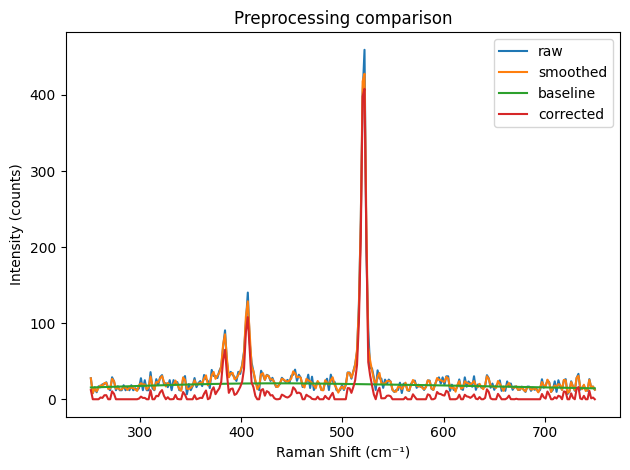


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
E12g                 383.67          4.80          61.76          2.40      
A1g                  406.28          4.91          108.49         2.45      
Si                   521.06          4.00          417.22         2.00      

E12g(Γ)-A1g(Γ) separation: 22.61 cm⁻¹

Normalized Residual: 0.0219 (0 = perfect fit)


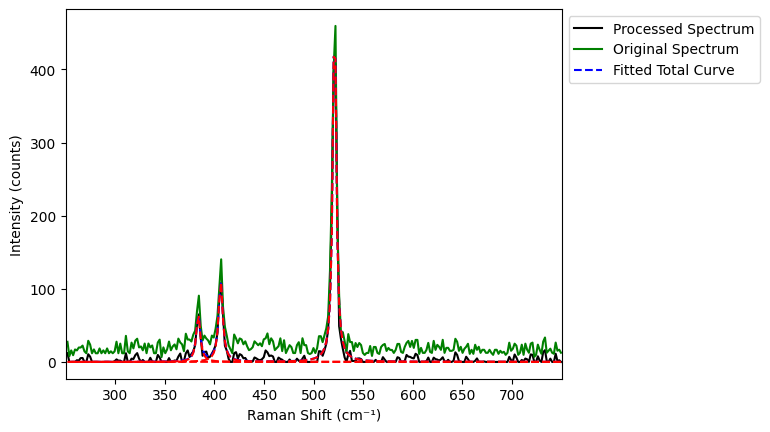

--- auto → ramanspy ---


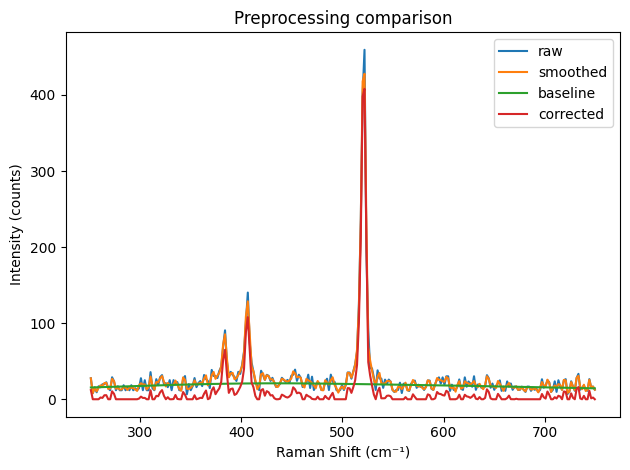


Peak                 Position(cm⁻¹)  FWHM(cm⁻¹)    Peak height    Scale     
--------------------------------------------------------------------------------
E12g                 383.67          4.79          61.76          2.40      
A1g                  406.28          4.91          108.48         2.45      
Si                   521.06          4.00          417.19         2.00      

E12g(Γ)-A1g(Γ) separation: 22.61 cm⁻¹

Normalized Residual: 0.0219 (0 = perfect fit)


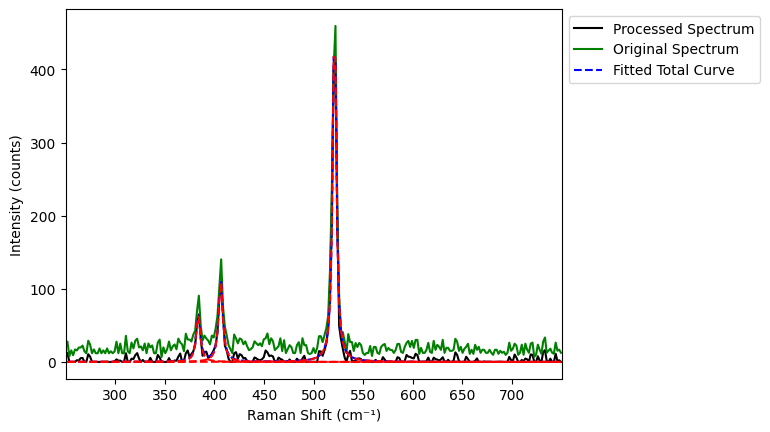

In [7]:
# plot_fit creates its own figure each call; call separately for each backend
print(f"--- native → {outcome_native['resolved_backend']} ---")
fit_native.plot_fit(fit_native.params_fit)

print(f"--- auto → {outcome_auto['resolved_backend']} ---")
fit_auto.plot_fit(fit_auto.params_fit)

## 7. Export provenance snippet

Export metadata records both the requested and resolved backend for reproducibility.

In [8]:
from ramanpl.single_fit._single_fit_core import build_single_fit_export_metadata

meta = build_single_fit_export_metadata(fit_auto)

provenance_keys = [
    "preprocessing_backend_requested",
    "preprocessing_backend_resolved",
    "preprocessing_backend_fallback_reason",  # only present when a fallback occurred
]
for k in provenance_keys:
    if k in meta:
        print(f"{k}: {meta[k]}")

preprocessing_backend_requested: auto
preprocessing_backend_resolved: ramanspy
